# 03_1 - ffNN normalizada en RAM

Version del `03_ffnn_normalizada` que carga las imagenes de train/valid una sola vez en memoria RAM. Mantiene la idea del `03`: estudiar el efecto de normalizar los pixeles, pero evita abrir `.tif` en cada batch. La normalizacion se hace dentro del modelo con `Rescaling(1./255)` para guardar los arrays como `uint8` y ahorrar memoria.


## Librerias y configuracion


In [1]:
import json
import math
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import rasterio
import warnings
from rasterio.errors import NotGeoreferencedWarning

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

print('GPUs disponibles:', tf.config.list_physical_devices('GPU'))


2026-06-23 17:48:24.573847: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782236904.788209      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782236904.854803      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782236905.380700      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782236905.380745      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782236905.380750      58 computation_placer.cc:177] computation placer alr

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# Kaggle-only: busca automaticamente xview_ann_train.json dentro de /kaggle/input.
KAGGLE_INPUT_DIR = Path('/kaggle/input')

if not KAGGLE_INPUT_DIR.exists():
    raise FileNotFoundError(
        'No existe /kaggle/input. Ejecuta este notebook en Kaggle y anade el dataset xview_recognition como Input.'
    )

json_matches = sorted(KAGGLE_INPUT_DIR.rglob('xview_ann_train.json'))
if not json_matches:
    available_inputs = [p.name for p in KAGGLE_INPUT_DIR.iterdir() if p.is_dir()]
    raise FileNotFoundError(
        'No se encontro xview_ann_train.json dentro de /kaggle/input. '
        f'Inputs disponibles: {available_inputs}. '
        'Comprueba que has anadido el dataset xview_recognition al notebook.'
    )

ANN_JSON = json_matches[0]
DATA_ROOT = ANN_JSON.parent
TRAIN_DIR = DATA_ROOT / 'xview_train'
TEST_DIR = DATA_ROOT / 'xview_test'
WORKDIR = Path('/kaggle/working')

print('DATA_ROOT:', DATA_ROOT)
print('ANN_JSON:', ANN_JSON)
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())


DATA_ROOT: /kaggle/input/datasets/eccvdl/xview-recognition
ANN_JSON: /kaggle/input/datasets/eccvdl/xview-recognition/xview_ann_train.json
TRAIN_DIR exists: True
TEST_DIR exists: True


## Datos


### Lectura del JSON


In [3]:
def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=NotGeoreferencedWarning)
    with rasterio.open(DATA_ROOT / filename, 'r') as src_raster:
        img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=src_raster.profile['dtype'])
        for band in range(src_raster.count):
            img[:, :, band] = src_raster.read(band + 1)
    return img


In [4]:
with open(ANN_JSON, 'r', encoding='utf-8') as f:
    json_data = json.load(f)

categories = {
    int(k): v['name']
    for k, v in sorted(json_data['categories'].items(), key=lambda item: int(item[0]))
}
category_names = list(categories.values())
category_to_idx = {name: idx for idx, name in categories.items()}
num_classes = len(category_names)

print('Categorias:')
print(categories)
print('Imagenes en JSON:', len(json_data['images']))
print('Anotaciones en JSON:', len(json_data['annotations']))


Categorias:
{0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}
Imagenes en JSON: 18746
Anotaciones en JSON: 18746


In [5]:
rows = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    rows.append({
        'image_id': json_img['image_id'],
        'filename': json_img['filename'],
        'width': json_img['width'],
        'height': json_img['height'],
        'category': json_ann['category_id'],
        'label': category_to_idx[json_ann['category_id']],
        'bbox': json_ann['bbox'],
        'exists': (DATA_ROOT / json_img['filename']).exists(),
    })

df = pd.DataFrame(rows)
print('Total train:', len(df))
print('Archivos encontrados:', int(df['exists'].sum()))
df.head()


Total train: 18746
Archivos encontrados: 18746


,image_id,filename,width,height,category,label,bbox,exists
0,0234476c-a017-4c9b-bd2f-872193076cca.tif,xview_train/Building/0234476c-a017-4c9b-bd2f-8...,224,224,Building,8,"[0, 0, 224, 224]",True
1,f2543073-9933-44c4-98e0-15eee2dffe2a.tif,xview_train/Building/f2543073-9933-44c4-98e0-1...,224,224,Building,8,"[0, 0, 224, 224]",True
2,6df5b6a5-82b0-4abb-8deb-7d7154c977bc.tif,xview_train/Building/6df5b6a5-82b0-4abb-8deb-7...,224,224,Building,8,"[0, 0, 224, 224]",True
3,ddbd2636-ce3c-4406-a5cf-92fa557dbd3c.tif,xview_train/Building/ddbd2636-ce3c-4406-a5cf-9...,224,224,Building,8,"[0, 0, 224, 224]",True
4,609064d1-3719-4163-ad36-577dab9805f0.tif,xview_train/Building/609064d1-3719-4163-ad36-5...,224,224,Building,8,"[0, 0, 224, 224]",True


Distribucion por clase:
category
Cargo plane            635
Small car             3324
Bus                   1768
Truck                 2210
Motorboat             1069
Fishing vessel         706
Dump truck            1236
Excavator              789
Building              3594
Helipad                111
Storage tank          1469
Shipping container    1523
Pylon                  312
Name: count, dtype: int64


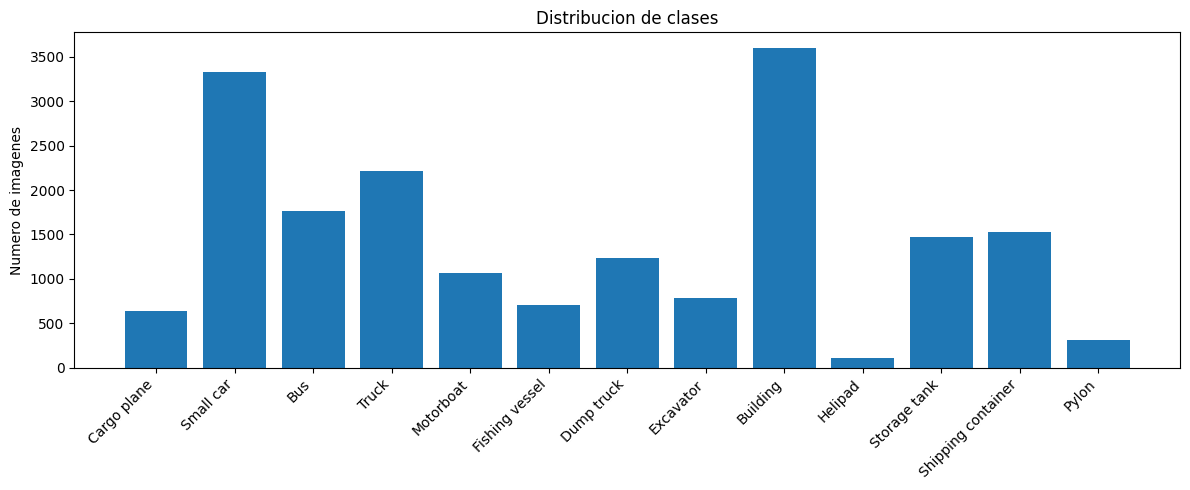

In [6]:
class_counts = df['category'].value_counts().reindex(category_names)
print('Distribucion por clase:')
print(class_counts)

plt.figure(figsize=(12, 5))
plt.bar(class_counts.index, class_counts.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Numero de imagenes')
plt.title('Distribucion de clases')
plt.tight_layout()
plt.show()


### Comprobacion de una imagen


Filename: xview_train/Building/0234476c-a017-4c9b-bd2f-872193076cca.tif
Shape: (224, 224, 3)
Dtype original: uint8
Min / Max original: 0 86
Etiqueta: Building
Indice de clase: 8
Bounding box: [0, 0, 224, 224]

Primeros pixeles del array original:
[[[45 30 19]
  [45 30 19]
  [46 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]]

Primeros pixeles normalizados:
[[[0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]
  [0.18039216 0.11764706 0.07450981]]

 [[0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]]

 [[0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]]]


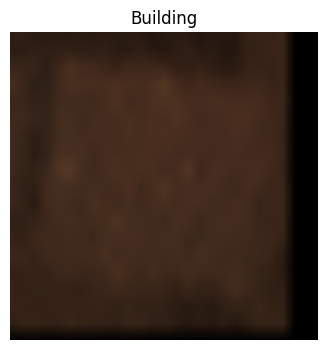

In [7]:
sample_row = df.iloc[0]
sample_img = load_geoimage(sample_row['filename'])
sample_img_norm = sample_img.astype(np.float32) / 255.0

print('Filename:', sample_row['filename'])
print('Shape:', sample_img.shape)
print('Dtype original:', sample_img.dtype)
print('Min / Max original:', sample_img.min(), sample_img.max())
print('Etiqueta:', sample_row['category'])
print('Indice de clase:', sample_row['label'])
print('Bounding box:', sample_row['bbox'])
print('')
print('Primeros pixeles del array original:')
print(sample_img[:3, :3, :])
print('')
print('Primeros pixeles normalizados:')
print(sample_img_norm[:3, :3, :])

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.title(sample_row['category'])
plt.axis('off')
plt.show()


### Split train/valid


In [8]:
train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    shuffle=True,
    stratify=df['label'],
)

print('Train:', len(train_df))
print('Validation:', len(val_df))

split_counts = pd.concat([
    train_df['category'].value_counts().reindex(category_names).rename('train'),
    val_df['category'].value_counts().reindex(category_names).rename('valid'),
], axis=1)
split_counts


Train: 15934
Validation: 2812


,train,valid
category,,
Cargo plane,540,95
Small car,2825,499
Bus,1503,265
Truck,1878,332
Motorboat,909,160
Fishing vessel,600,106
Dump truck,1051,185
Excavator,671,118
Building,3055,539


### Carga en memoria RAM

Cargamos train y valid una sola vez como `uint8`. La normalizacion se hace dentro del modelo con una capa `Rescaling(1./255)`, para evitar guardar todo el dataset como `float32` en memoria.


In [9]:
def dataframe_to_arrays(data):
    images = np.stack([load_geoimage(filename) for filename in data['filename']]).astype(np.uint8)
    labels_idx = data['label'].to_numpy(dtype=np.int32)
    labels = tf.keras.utils.to_categorical(labels_idx, num_classes=num_classes).astype(np.float32)
    return images, labels, labels_idx

X_train, y_train, y_train_idx = dataframe_to_arrays(train_df)
X_valid, y_valid, y_valid_idx = dataframe_to_arrays(val_df)

print('X_train:', X_train.shape, X_train.dtype, 'RAM aprox:', X_train.nbytes / 1024**3, 'GB')
print('X_valid:', X_valid.shape, X_valid.dtype, 'RAM aprox:', X_valid.nbytes / 1024**3, 'GB')
print('y_train:', y_train.shape, y_train.dtype)
print('y_valid:', y_valid.shape, y_valid.dtype)


X_train: (15934, 224, 224, 3) uint8 RAM aprox: 2.2337894439697266 GB
X_valid: (2812, 224, 224, 3) uint8 RAM aprox: 0.3942146301269531 GB
y_train: (15934, 13) float32
y_valid: (2812, 13) float32


## Red


### Arquitectura y summary


In [10]:
BATCH_SIZE = 64
EPOCHS = 30

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    tf.keras.layers.Rescaling(1.0 / 255.0),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax'),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()


I0000 00:00:1782237497.892550      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782237497.898825      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    38,535,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,569,997 (147.13 MB)

 Trainable params: 38,569,997 (147.13 MB)

 Non-trainable params: 0 (0.00 B)

### Callbacks


In [11]:
MODEL_PATH = WORKDIR / '03_1_ffnn_normalizada_ram.keras'
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(str(MODEL_PATH), monitor='val_accuracy', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.TerminateOnNaN(),
]

print('Modelo guardado en:', MODEL_PATH)


Modelo guardado en: /kaggle/working/03_1_ffnn_normalizada_ram.keras


### Entrenamiento


In [12]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

best_idx = int(np.argmax(history.history['val_accuracy']))
best_value = float(np.max(history.history['val_accuracy']))
print('Best validation model: epoch', best_idx + 1, '- val_accuracy', best_value)


Epoch 1/30


I0000 00:00:1782237505.796087     152 service.cc:152] XLA service 0x7e1650006470 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782237505.796146     152 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782237505.796153     152 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782237506.089576     152 cuda_dnn.cc:529] Loaded cuDNN version 91002


 16/249 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.1103 - loss: 10.3882

I0000 00:00:1782237507.527348     152 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2340 - loss: 4.4795
Epoch 1: val_accuracy improved from None to 0.26102, saving model to /kaggle/working/03_1_ffnn_normalizada_ram.keras

Epoch 1: finished saving model to /kaggle/working/03_1_ffnn_normalizada_ram.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.2960 - loss: 2.8463 - val_accuracy: 0.2610 - val_loss: 2.3013 - learning_rate: 3.0000e-04
Epoch 2/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3705 - loss: 2.0211
Epoch 2: val_accuracy improved from 0.26102 to 0.35100, saving model to /kaggle/working/03_1_ffnn_normalizada_ram.keras

Epoch 2: finished saving model to /kaggle/working/03_1_ffnn_normalizada_ram.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.3779 - loss: 1.9912 - val_accuracy: 0.3510 - val_loss: 1.9067 - learning_rate: 3.0000e-04
Epoch 3/30
246/249 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4047 - loss: 1.8023
Epoch 3: val_accuracy improved from 0.35100 to 0.45555

## Resultados


### Graficas de entrenamiento


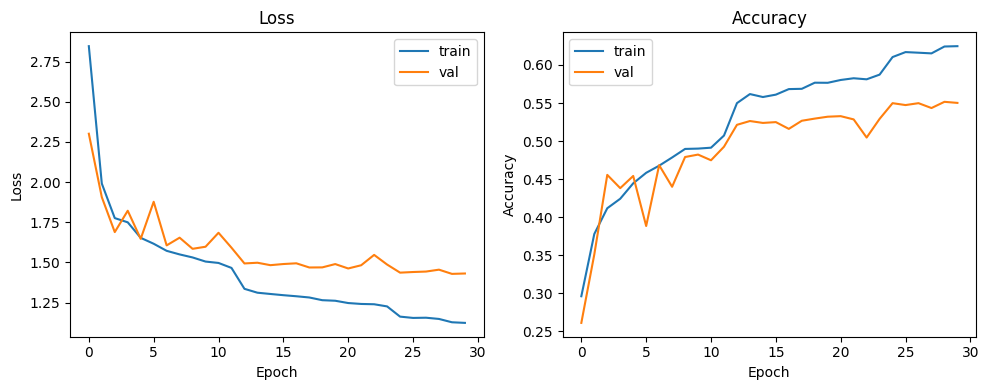

In [13]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### Matriz de confusion


In [14]:
model.load_weights(MODEL_PATH)
probs = model.predict(X_valid, batch_size=BATCH_SIZE, verbose=1)
y_pred_idx = np.argmax(probs, axis=1)
y_true_idx = y_valid_idx

cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(num_classes)))


44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


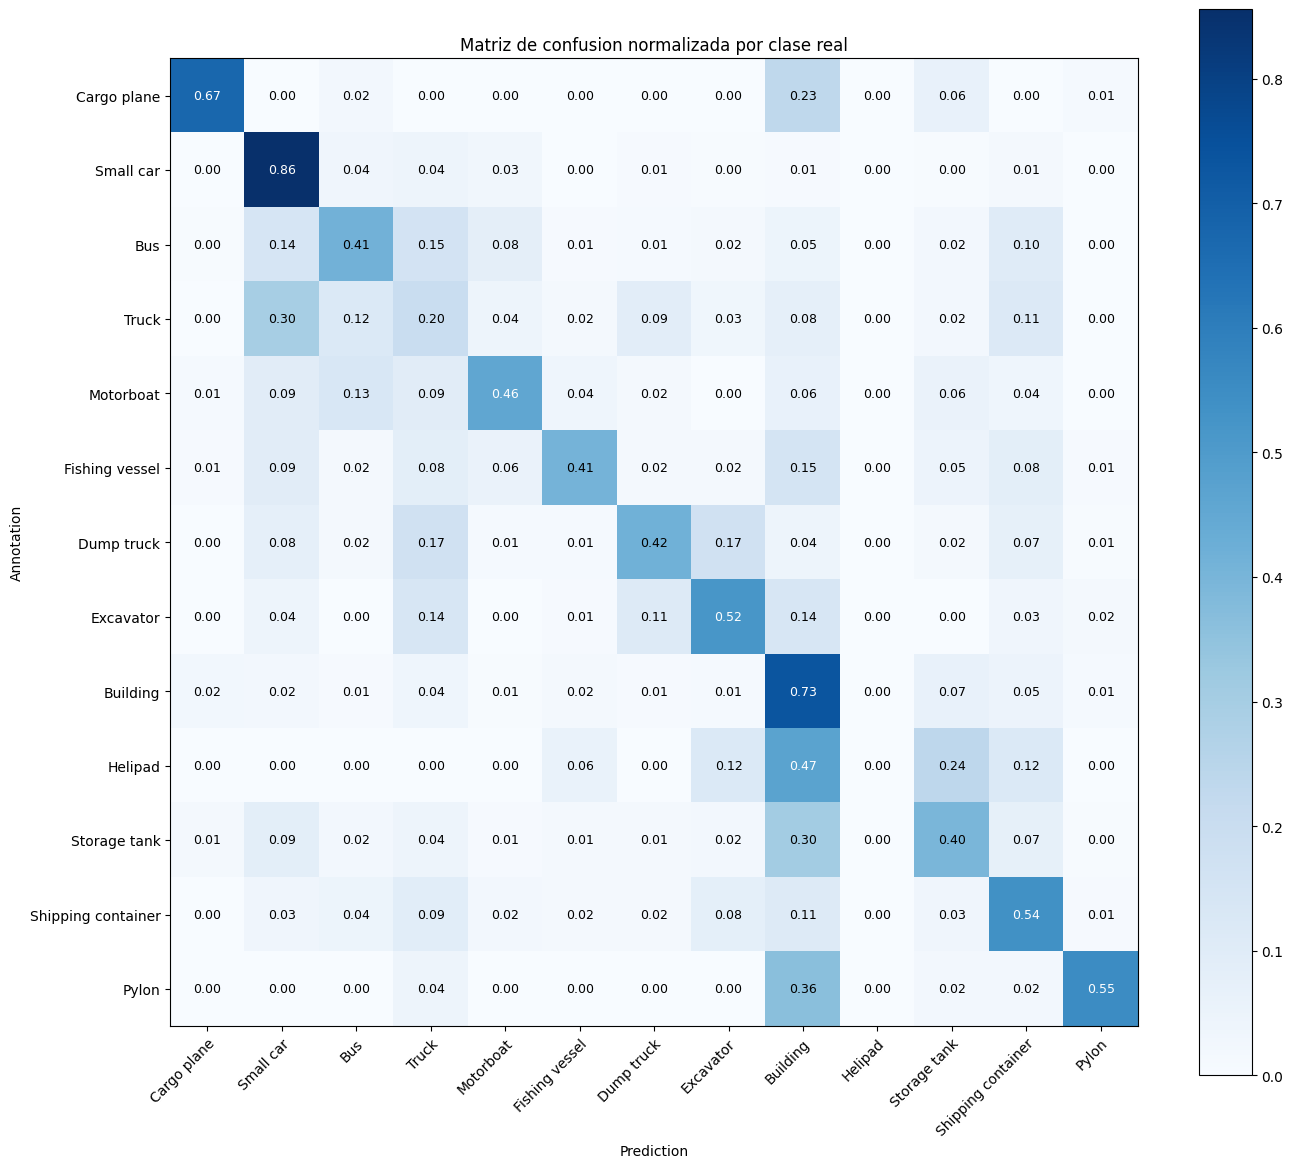

In [15]:
def draw_confusion_matrix_percent(cm, labels):
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), np.finfo(np.float64).eps)

    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.colormaps['Blues'], vmin=0.0, vmax=max(0.01, cm_norm.max()))
    fig.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel='Annotation',
        xlabel='Prediction',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    threshold = cm_norm.max() / 2.0
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            value = cm_norm[i, j]
            ax.text(
                j,
                i,
                f'{value:.2f}',
                ha='center',
                va='center',
                color='white' if value > threshold else 'black',
                fontsize=9,
            )

    ax.set_title('Matriz de confusion normalizada por clase real')
    fig.tight_layout()
    plt.show()

draw_confusion_matrix_percent(cm, category_names)


### Metricas por clase


In [16]:
correct = np.diag(cm).astype(float)
total_true = np.sum(cm, axis=1).astype(float)
total_pred = np.sum(cm, axis=0).astype(float)

print('Mean Accuracy: %.3f%%' % (np.sum(correct) / np.sum(total_true) * 100))
print('Mean Recall: %.3f%%' % ((correct / np.maximum(total_true, np.finfo(np.float64).eps)).mean() * 100))
print('Mean Precision: %.3f%%' % ((correct / np.maximum(total_pred, np.finfo(np.float64).eps)).mean() * 100))

for idx, name in enumerate(category_names):
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    recall = tp / np.maximum(tp + fn, np.finfo(np.float64).eps)
    precision = tp / np.maximum(tp + fp, np.finfo(np.float64).eps)
    specificity = tn / np.maximum(tn + fp, np.finfo(np.float64).eps)
    f1_score = 2 * ((precision * recall) / np.maximum(precision + recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (name, recall * 100, precision * 100, specificity * 100, f1_score * 100))


Mean Accuracy: 55.156%
Mean Recall: 47.332%
Mean Precision: 49.662%
> Cargo plane: Recall: 67.368% Precision: 76.190% Specificity: 99.264% Dice: 71.508%
> Small car: Recall: 85.571% Precision: 66.099% Specificity: 90.532% Dice: 74.585%
> Bus: Recall: 41.132% Precision: 51.174% Specificity: 95.917% Dice: 45.607%
> Truck: Recall: 19.880% Precision: 26.190% Specificity: 92.500% Dice: 22.603%
> Motorboat: Recall: 45.625% Precision: 51.773% Specificity: 97.436% Dice: 48.505%
> Fishing vessel: Recall: 40.566% Precision: 55.128% Specificity: 98.707% Dice: 46.739%
> Dump truck: Recall: 41.622% Precision: 54.225% Specificity: 97.526% Dice: 47.095%
> Excavator: Recall: 51.695% Precision: 43.262% Specificity: 97.030% Dice: 47.104%
> Building: Recall: 73.284% Precision: 63.099% Specificity: 89.837% Dice: 67.811%
> Helipad: Recall: 0.000% Precision: 0.000% Specificity: 99.964% Dice: 0.000%
> Storage tank: Recall: 39.545% Precision: 50.000% Specificity: 96.644% Dice: 44.162%
> Shipping container: Re

## Codabench

El conjunto test no tiene etiquetas publicas. Esta seccion recorre `xview_test`, genera `prediction.json` y lo comprime como `submission.zip` para Codabench.


In [17]:
test_files = sorted(TEST_DIR.rglob('*.tif'))
print('Number of testing images:', len(test_files))

assert len(test_files) > 0, 'No se encontraron imagenes .tif en TEST_DIR.'


Number of testing images: 2365


In [18]:
model.load_weights(MODEL_PATH)
predictions_data = {'images': {}, 'annotations': {}}
batch_size = 64

for start in range(0, len(test_files), batch_size):
    batch_paths = test_files[start:start + batch_size]

    # Ruta para guardar en el JSON: relativa a xview_test.
    json_filenames = [path.relative_to(TEST_DIR).as_posix() for path in batch_paths]

    # Ruta para leer con load_geoimage: relativa a DATA_ROOT.
    load_filenames = [path.relative_to(DATA_ROOT).as_posix() for path in batch_paths]

    images = np.stack([load_geoimage(filename) for filename in load_filenames]).astype(np.uint8)
    probs = model.predict(images, batch_size=batch_size, verbose=0)
    pred_idx = np.argmax(probs, axis=1)
    pred_scores = np.max(probs, axis=1)

    for offset, (path, json_filename, cls_idx, score) in enumerate(zip(batch_paths, json_filenames, pred_idx, pred_scores)):
        idx = start + offset
        predictions_data['images'][idx] = {
            'image_id': path.name,
            'filename': json_filename,
            'width': 224,
            'height': 224,
        }
        predictions_data['annotations'][idx] = {
            'image_id': path.name,
            'category_id': category_names[int(cls_idx)],
            'score': float(score),
            'bbox': [0, 0, 224, 224],
        }

    print(f'Procesadas {min(start + batch_size, len(test_files))}/{len(test_files)}')

assert len(predictions_data['images']) == len(test_files)
assert len(predictions_data['annotations']) == len(test_files)

prediction_path = WORKDIR / 'prediction_03_1.json'
submission_path = WORKDIR / 'submission_03_1.zip'

with open(prediction_path, 'w', encoding='utf-8') as outfile:
    json.dump(predictions_data, outfile)

with zipfile.ZipFile(submission_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(prediction_path, arcname='prediction.json')

print('Archivos generados:')
print(prediction_path, '-', prediction_path.stat().st_size, 'bytes')
print(submission_path, '-', submission_path.stat().st_size, 'bytes')

from IPython.display import FileLink, display
display(FileLink(str(submission_path)))


Procesadas 64/2365
Procesadas 128/2365
Procesadas 192/2365
Procesadas 256/2365
Procesadas 320/2365
Procesadas 384/2365
Procesadas 448/2365
Procesadas 512/2365
Procesadas 576/2365
Procesadas 640/2365
Procesadas 704/2365
Procesadas 768/2365
Procesadas 832/2365
Procesadas 896/2365
Procesadas 960/2365
Procesadas 1024/2365
Procesadas 1088/2365
Procesadas 1152/2365
Procesadas 1216/2365
Procesadas 1280/2365
Procesadas 1344/2365
Procesadas 1408/2365
Procesadas 1472/2365
Procesadas 1536/2365
Procesadas 1600/2365
Procesadas 1664/2365
Procesadas 1728/2365
Procesadas 1792/2365
Procesadas 1856/2365
Procesadas 1920/2365
Procesadas 1984/2365
Procesadas 2048/2365
Procesadas 2112/2365
Procesadas 2176/2365
Procesadas 2240/2365
Procesadas 2304/2365
Procesadas 2365/2365
Archivos generados:
/kaggle/working/prediction_03_1.json - 730231 bytes
/kaggle/working/submission_03_1.zip - 165665 bytes


/kaggle/working/submission_03_1.zip